In [2]:
from utils import * 
import json 

%load_ext autoreload 
%autoreload 2

In [17]:
GENOME_CONTIG_IDS = dict()
GENOME_CONTIG_IDS['bz_0'] = []
GENOME_CONTIG_IDS['bz_1'] = ['Landfill_SRR22315504_scaffold_40513', 'Landfill_SRR22315504_scaffold_124901']
GENOME_CONTIG_IDS['bz_2'] = ['Dalian_Groundwater_SRR22387926_scaffold_5929']
GENOME_CONTIG_IDS['bz_3'] = ['Mangrove_60-80cm_incl_SRR17658263_scaffold_5020']
GENOME_CONTIG_IDS['bz_4'] = ['Nantong_Groundwater_SRR22387873_scaffold_1350']
GENOME_CONTIG_IDS['bz_5'] = ['Nantong_Groundwater_SRR22387873_scaffold_2044']
GENOME_CONTIG_IDS['bz_7'] = ['RifSed_csp1_16ft_4_scaffold_2135']
GENOME_CONTIG_IDS['bz_8'] = ['Shanghai_Industrial_Park_soil_SRR23875558_scaffold_1066']
GENOME_CONTIG_IDS['bz_9'] = ['SRR17498766_aquifer_sediment_scaffold_1816', 'SRR17498766_aquifer_sediment_scaffold_47226', 'SRR17498766_aquifer_sediment_scaffold_61411']
GENOME_CONTIG_IDS['bz_10'] = ['SRR17498766_aquifer_sediment_scaffold_6555', 'SRR17498766_aquifer_sediment_scaffold_7403', 'SRR17498766_aquifer_sediment_scaffold_93350']
GENOME_CONTIG_IDS['bz_11'] = ['SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886', 'SR-VP_9_9_2021_31_2B_1_5m_scaffold_14874', 'SR-VP_9_9_2021_72_4B_1_05m_2_scaffold_578826', 'SR-VP_9_9_2021_56_4A_0_95m_scaffold_5485', 'SR-VP_9_9_2021_72_4B_1_05m_2_METASPADES_scaffold_91666']



In [18]:
GENOMES_DIR = '../data/genomes'
GENES_DIR = '/home/prichter/Documents/banfield/betazoid/data/genes'

ORFM_MIN_LENGTH = 90

for path in glob.glob(os.path.join(GENOMES_DIR, '*')):
    genome_id = os.path.basename(path).replace('.fasta', '')
    aa_output_path = os.path.join(GENES_DIR, 'prodigal', f'{genome_id}.faa')
    nt_output_path = os.path.join(GENES_DIR, 'prodigal', f'{genome_id}.fna')
    if not os.path.exists(aa_output_path):
        subprocess.run(f'prodigal -a {aa_output_path} -d {nt_output_path} -i {path} -p meta', shell=True, check=True)

for path in glob.glob(os.path.join(GENOMES_DIR, '*')):
    genome_id = os.path.basename(path).replace('.fasta', '')
    aa_output_path = os.path.join(GENES_DIR, 'orfm', f'{genome_id}.faa')
    nt_output_path = os.path.join(GENES_DIR, 'orfm', f'{genome_id}.fna')
    if not os.path.exists(aa_output_path):
        subprocess.run(f'orfm -t {nt_output_path} {path} > {aa_output_path}', shell=True, check=True)

In [19]:
def _get_start_codon(nt_seq:str, info:dict=None, start_codons=['ATG', 'GTG', 'TTG'], stop_codons=['TAA', 'TAG', 'TGA']):
    ''''''
    assert len(nt_seq) % 3 == 0, f'_get_start_codon: Expected the nucleotide sequence to be divisible by three, got {len(nt_seq)}.'
    codons = np.array([nt_seq[i:i + 3] for i in range(0, len(nt_seq), 3)])
    codons = [codon for codon in codons if (codon not in stop_codons)] # The Prodigal nucleotide sequence includes the stop codon, while OrfM seems to not.
    
    info['has_start_codon'] = np.any(np.isin(codons, start_codons))
    if info['has_start_codon']:
        start_codon_idx = np.where(np.isin(codons, start_codons))[0][0]
        info['length_from_start_codon'] = len(codons) - start_codon_idx # Gets position of first start codon. 
        info['start_codon_idx'] = start_codon_idx
        info['start_codon'] = codons[start_codon_idx]
        # print(info['strand'], codons, info['start_codon'], start_codon_idx)
    return info

def orfm_parse_entry(row):
    '''ORFm gene IDs are of the form {sequence_name}_{start}_{stop}_{frame}. The start coordinate is inclusive, so needs to be shifted by 1 to the left. Additionally, 
    it does not include the stop codon itself, whereas the Prodigal coordinates do, so the start coordinate needs to be shifted 3 positions to the left if the gene is predicted
    on the reverse strand. See https://github.com/wwood/OrfM for more details.'''
    gene_id = row.gene_id.split('_')
    info = dict()
    info['start'], info['frame'], info['gene_number'] = [int(x) for x in gene_id[-3:]]
    info['start'] = info['start'] - 1 
    info['strand'] = '+' if (info['frame'] <= 3) else '-'
    info['start'] = info['start'] - 3 if (info['strand'] == '-') else info['start']
    info['stop'] = info['start'] + (len(row.seq) * 3) + 3  
    info = _get_start_codon(row.nt_seq, info=info)
    return info

def prodigal_parse_entry(row):
    '''Parse the info contained in the Prodigal output description line.'''
    header_pattern = r'# (?P<start>\d+) # (?P<stop>\d+) # (?P<strand>[\d\-]+) # ID\=\d+_(?P<gene_number>\d+)'
    info = re.search(header_pattern, row.description).groupdict()
    info['gene_number'], info['start'], info['stop'] = int(info['gene_number']), int(info['start']) - 1, int(info['stop'])
    info['partial'] = re.search(r'partial=(\d+)', row.description).group(1)
    info['strand'] = '+' if (info['strand'] == '1') else '-'
    info = _get_start_codon(row.nt_seq, info=info)
    return info


def load_genes(tool:str, parser=None, genome_ids=GENOME_CONTIG_IDS.keys()):
    genes_df = list()
    for genome_id in genome_ids:

        aa_df = FASTAFile.from_file(os.path.join(GENES_DIR, tool, f'{genome_id}.faa')).to_df() # Write the amino acid sequences to the FASTA file. 
        nt_df = FASTAFile.from_file(os.path.join(GENES_DIR, tool, f'{genome_id}.fna')).to_df().rename(columns={'seq':'nt_seq'}).drop(columns=['description'])
        df = pd.concat([nt_df, aa_df], axis=1).reset_index(names='gene_id')

        df_ = pd.DataFrame(df.apply(parser, axis=1).apply(pd.Series)) # Convert each dictionary to a pandas Series, and then to a DataFrame. 
        df = pd.concat([df, df_], axis=1)

        df['genome_id'] = genome_id
        df['seq'] = df.seq.str.replace('*', '') # Remove the terminal asterisk. 
        df['nt_seq'] = df.nt_seq.str.replace('*', '') # Remove the terminal asterisk. 
        df['gene_id'] = [f'{tool}.{genome_id}.1_{int(row.gene_number)}' for row in df.itertuples()]
        genes_df.append(df)
    return pd.concat(genes_df).set_index('gene_id')

genes_df = load_genes('orfm', parser=orfm_parse_entry)

In [20]:
def _get_prodigal_gene(start:int=None, strand:str=None, stop:int=None, genome_id:str=None, genes_df_prodigal=None):
    '''For an OrfM prediction, get the Prodigal-predicted gene which is on the same strand, in the same frame, and overlaps'''
    mask = (genome_id == genes_df_prodigal.genome_id)
    mask = mask & (genes_df_prodigal.strand == strand) # Make sure ORFs are predicted on the same strand. 
    mask = mask & ((genes_df_prodigal.stop == stop) | (genes_df_prodigal.start == start))

    if mask.sum() == 0:
        return None
    if mask.sum() > 1:
        raise Exception(f'orfm_get_matching_prodigal_gene: Expecting only one corresponding Prodigal gene, but got {mask.sum()}.')
    return genes_df_prodigal[mask].iloc[0]


def get_prodigal_genes(genes_df, genes_df_prodigal=load_genes('prodigal', parser=prodigal_parse_entry)):

    for row in genes_df.itertuples():
        output = _get_prodigal_gene(start=row.start, stop=row.stop, strand=row.strand, genome_id=row.genome_id, genes_df_prodigal=genes_df_prodigal)
        if output is None:
            genes_df.loc[row.Index, 'prodigal_seq'] = output.seq if (output is not None) else '' 
            genes_df.loc[row.Index, 'prodigal_nt_seq'] = output.nt_seq if (output is not None) else '' 
            genes_df.loc[row.Index, 'prodigal_length_from_start_codon'] = row.length_from_start_codon
            continue 
        genes_df.loc[row.Index, 'prodigal_partial'] = output.partial
        genes_df.loc[row.Index, 'prodigal_gene_id'] = output.name
        genes_df.loc[row.Index, 'prodigal_length_from_start_codon'] = output.length_from_start_codon 
        genes_df.loc[row.Index, 'prodigal_seq'] = output.seq 
        genes_df.loc[row.Index, 'prodigal_nt_seq'] = output.nt_seq 
        genes_df.loc[row.Index, 'prodigal_start_idx'] = row.length_from_start_codon - output.length_from_start_codon

    counts = [(genes_df.prodigal_gene_id.values == gene_id).sum() for gene_id in genes_df_prodigal.index.unique()]
    assert np.all(np.array(counts) == 1), 'Every Prodigal gene ID should have exactly one corresponding OrfM sequence.'

    return genes_df


genes_df = get_prodigal_genes(genes_df)

In [21]:
def trim_genes(genes_df:pd.DataFrame):
    genes_df['seq_untrimmed'] = genes_df.seq.copy()
    genes_df['nt_seq_untrimmed'] = genes_df.nt_seq.copy()
    genes_df['seq'] = [(row.seq[int(row.start_codon_idx):] if row.has_start_codon else row.seq) for row in genes_df.itertuples()]
    genes_df['nt_seq'] = [(row.nt_seq[int(row.start_codon_idx * 3):] if row.has_start_codon else row.nt_seq) for row in genes_df.itertuples()]
    genes_df['n_residues_trimmed'] = genes_df.seq_untrimmed.apply(len) - genes_df.seq.apply(len) 

    for row in genes_df.itertuples():
        if not row.has_start_codon:
            continue 
        assert row.nt_seq[:3] == row.start_codon, f'trim_sequence_to_start_codon: First codon is not the expected start codon. Saw {row.nt_seq[:3]}, expected {row.start_codon}.'
        assert len(row.seq) == row.length_from_start_codon, f'trim_sequence_to_start_codon: Sequence is not the expected length. Sequence has length {len(row.seq)}, expected {row.length_from_start_codon}.'
    n_trimmed = (genes_df.seq_untrimmed != genes_df.seq).sum()
    print(f'trim_genes: Trimmed {n_trimmed} of {len(genes_df)} genes to the first start codon.')
    return genes_df


def filter_genes(genes_df:pd.DataFrame, min_length:int=10):  
    masks = dict()
    masks['no_start_codon'] = (~genes_df.has_start_codon) & genes_df.prodigal_gene_id.isnull() # Keep genes without a start codon if Prodigal also predicts them to be partial.
    masks['shorter_than_min_length'] = (genes_df.length_from_start_codon < min_length) & genes_df.has_start_codon 

    mask = None
    for name, mask_ in masks.items():
        print(f'filter_genes: Removing {mask_.sum()} genes failing filter {name}.')
        mask = mask_ if (mask is None) else mask | mask_
    genes_df = genes_df[~mask].copy()
    return genes_df


genes_df_untrimmed_unfiltered = genes_df.copy() # Store the unfiltered, untrimmed sequences. 
FASTAFile.from_df(genes_df_untrimmed_unfiltered).write(os.path.join(GENES_DIR, 'genes_untrimmed_unfiltered.faa'))

genes_df = filter_genes(trim_genes(genes_df)) # Store the filtered, trimmed sequences. 
FASTAFile.from_df(genes_df).write(os.path.join(GENES_DIR, 'genes.faa'))

trim_genes: Trimmed 1553 of 2154 genes to the first start codon.
filter_genes: Removing 499 genes failing filter no_start_codon.
filter_genes: Removing 121 genes failing filter shorter_than_min_length.


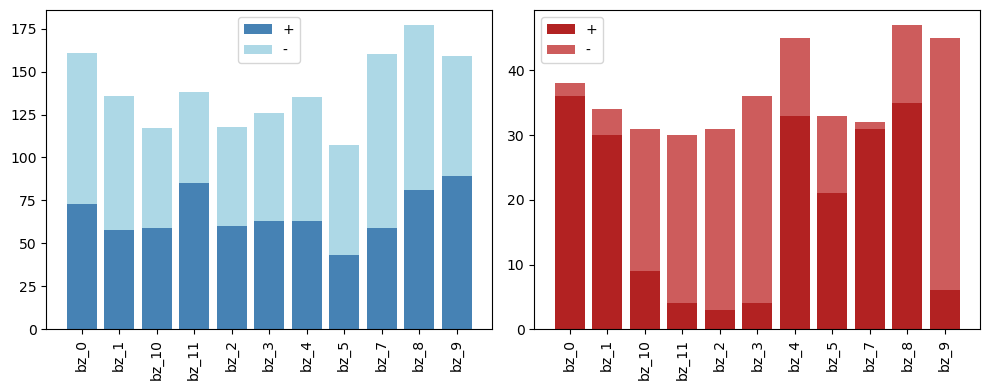

In [22]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

figure_df = genes_df.groupby('genome_id').size().reset_index(name='n_genes')
figure_df['n_genes_forward_strand'] = figure_df.genome_id.map(genes_df[genes_df.strand == '+'].groupby('genome_id').size())
figure_df['n_genes_reverse_strand'] = figure_df.genome_id.map(genes_df[genes_df.strand == '-'].groupby('genome_id').size())

ax = axes[0]
ax.bar(x=np.arange(len(figure_df)), height=figure_df.n_genes_forward_strand, label='+', color='steelblue')
ax.bar(x=np.arange(len(figure_df)), height=figure_df.n_genes_reverse_strand, bottom=figure_df.n_genes_forward_strand, label='-', color='lightblue')
ax.legend()
ax.set_xticks(np.arange(len(figure_df)), labels=figure_df.genome_id, rotation=90)

figure_df = genes_df[~genes_df.prodigal_gene_id.isnull()].groupby('genome_id').size().reset_index(name='n_genes')
figure_df['n_genes_forward_strand'] = figure_df.genome_id.map(genes_df[(genes_df.strand == '+') & ~genes_df.prodigal_gene_id.isnull()].groupby('genome_id').size())
figure_df['n_genes_reverse_strand'] = figure_df.genome_id.map(genes_df[(genes_df.strand == '-') & ~genes_df.prodigal_gene_id.isnull()].groupby('genome_id').size())

ax = axes[1]
ax.bar(x=np.arange(len(figure_df)), height=figure_df.n_genes_forward_strand, label='+', color='firebrick')
ax.bar(x=np.arange(len(figure_df)), height=figure_df.n_genes_reverse_strand, bottom=figure_df.n_genes_forward_strand, label='-', color='indianred')
ax.legend()
ax.set_xticks(np.arange(len(figure_df)), labels=figure_df.genome_id, rotation=90)

fig.tight_layout()
plt.show()

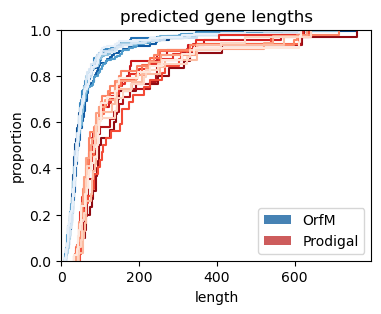

In [25]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = genes_df.copy()
figure_df['length'] = figure_df.seq.apply(len)

sns.ecdfplot(figure_df, x='length', hue='genome_id', ax=ax, palette='Blues', legend=False)
sns.ecdfplot(figure_df[~figure_df.prodigal_gene_id.isnull()], x='length', hue='genome_id', palette='Reds', ax=ax, legend=False)
# sns.kdeplot(figure_df, x='length', hue='genome_id', ax=axes[0], palette='Blues', common_norm=True)
# sns.kdeplot(figure_df[~figure_df.prodigal_gene_id.isnull()], x='length', hue='genome_id', palette='Reds', common_norm=True)
ax.set_xlim(xmin=0)
ax.set_ylabel('proportion')
ax.set_title('predicted gene lengths')
ax.legend(handles=[Patch(facecolor='steelblue'), Patch(facecolor='indianred')], labels=['OrfM', 'Prodigal'])

plt.show()

In [ ]:
# Also want to look at GC content of various genes... 

In [10]:
cluster_df = pd.read_csv('../data/genes/genes_cluster.tsv', sep='\t', header=None, names=['rep_gene_id', 'gene_id'])
cluster_df['genome_id'] = [re.search(r'bz_\d+', gene_id).group(0) for gene_id in cluster_df.gene_id]
cluster_df['cluster_size'] = cluster_df.rep_gene_id.map(cluster_df.groupby('rep_gene_id').size())
cluster_df['cluster_n_genomes'] = cluster_df.rep_gene_id.map(cluster_df.groupby('rep_gene_id').genome_id.nunique())

genes_df = genes_df.reset_index().copy()
genes_df = genes_df.drop(columns=[col for col in genes_df.columns if (col in cluster_df.columns) and (col != 'gene_id')])
genes_df = genes_df.merge(cluster_df.drop(columns='genome_id'), on='gene_id', how='left')
genes_df['conserved'] = genes_df.cluster_n_genomes > 1

print('Num. clusters:', cluster_df.rep_gene_id.nunique())
print('Num. clusters with genes in > 1 genome:', (cluster_df.drop_duplicates('rep_gene_id').cluster_n_genomes > 1).sum())
print('Num. clusters with genes in > 5 genomes:', (cluster_df.drop_duplicates('rep_gene_id').cluster_n_genomes > 5).sum())
print('Num. clusters with genes in > 10 genomes:', (cluster_df.drop_duplicates('rep_gene_id').cluster_n_genomes > 10).sum())
print('Num. conserved genes not predicted by Prodigal:', (genes_df.conserved & genes_df.prodigal_gene_id.isnull()).sum())

Num. clusters: 1350
Num. clusters with genes in > 1 genome: 66
Num. clusters with genes in > 5 genomes: 7
Num. clusters with genes in > 10 genomes: 1
Num. conserved genes not predicted by Prodigal: 22


In [11]:
fields = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
annot_df = pd.read_csv('../data/genes/genes.tsv', sep='\t', header=None, names=fields)

genes_df['annotated'] = genes_df.gene_id.isin(annot_df.gene_id.unique())
genes_df['annotated_consensus_disorder_only'] = genes_df.gene_id.map(annot_df.groupby('gene_id').apply(lambda df : np.all(df.analysis == 'MobiDBLite'), include_groups=False))
genes_df['annotated_consensus_disorder_only'] = genes_df['annotated_consensus_disorder_only']
genes_df['has_annotation'] = genes_df.gene_id.isin(annot_df.gene_id.unique())
genes_df['annotation_start'] = genes_df.gene_id.map(annot_df.groupby('gene_id').annotation_start.min())
genes_df['annotation_stop'] = genes_df.gene_id.map(annot_df.groupby('gene_id').annotation_stop.max())

print('Num. genes with only consensus disorder predictions:', genes_df.annotated_consensus_disorder_only.sum())
print('Num. genes with any annotation:',  genes_df.annotated.sum())
print('Num. conserved genes with any annotation:', (genes_df.conserved & genes_df.annotated).sum())
print('Num. non-conserved genes with any annotation:', ((~genes_df.conserved) & genes_df.annotated).sum())
print('Num. annotated genes not predicted by Prodigal:', (genes_df.annotated & genes_df.prodigal_gene_id.isnull()).sum())
print('Num. annotated genes not predicted by Prodigal (excluding consensus disorder predictions):', (genes_df.annotated & genes_df.prodigal_gene_id.isnull() & (genes_df.annotated_consensus_disorder_only == True)).sum())

fields = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
annot_df_unfiltered = pd.read_csv('../data/genes/genes_untrimmed_unfiltered.tsv', sep='\t', header=None, names=fields)
annot_df_unfiltered = annot_df_unfiltered[~annot_df_unfiltered.gene_id.isin(annot_df.gene_id.unique())].copy() # Remove genes which already have annotations.
annot_df_unfiltered['removed_by_filter'] = ~annot_df_unfiltered.gene_id.isin(genes_df.gene_id.unique())
annot_df_unfiltered['n_residues_trimmed'] = annot_df_unfiltered.gene_id.map(genes_df.set_index('gene_id').n_residues_trimmed)

print('\nNum. proteins removed by filter with an annotation:', annot_df_unfiltered[annot_df_unfiltered.removed_by_filter].gene_id.nunique())
print('Num. proteins not removed by filter which have an annotation only when untrimmed:', annot_df_unfiltered[~annot_df_unfiltered.removed_by_filter].gene_id.nunique())

Num. genes with only consensus disorder predictions: 17
Num. genes with any annotation: 89
Num. conserved genes with any annotation: 44
Num. non-conserved genes with any annotation: 45
Num. annotated genes not predicted by Prodigal: 17
Num. annotated genes not predicted by Prodigal (excluding consensus disorder predictions): 9

Num. proteins removed by filter with an annotation: 16
Num. proteins not removed by filter which have an annotation only when untrimmed: 13


In [15]:
# ALPHAFOLD_JSON_TEMPLATE = {'name':None, 'sequences':[{'protein':{'id':None, 'sequence':None}}], 'modelSeeds':[1], 'dialect':'alphafold3', 'version':1}

# for row in genes_df.itertuples():
#     with open(f'../data/genes/alphafold/{row.gene_id}.json', 'w') as f:
#       input = ALPHAFOLD_JSON_TEMPLATE.copy()
#       input['name'] = row.gene_id 
#       input['sequences'] = [{'protein':{'id':row.gene_id, 'sequence':row.seq}}]
#       json.dump(input, f)

genes_df[genes_df.gene_id.str.contains('bz_0') & ~genes_df.prodigal_gene_id.isnull()].frame.value_counts()

frame
2    13
3    12
1    11
4     1
6     1
Name: count, dtype: int64

In [ ]:
annot_df['prodigal_start_idx'] = annot_df.gene_id.map(genes_df.set_index('gene_id').prodigal_start_idx)
annot_df[annot_df.annotation_start < annot_df.prodigal_start_idx]

,gene_id,checksum,length,analysis,signature_accession,signature_description,annotation_start,annotation_stop,annotation_e_value,annotation_status,date,interpro_accession,interpro_description,go_terms,pathways,prodigal_start_idx
36,orfm.bz_4.1_40,aaf24c33f0fb9558d3cf3ea701a3100a,74,Coils,Coil,Coil,1,21,-,T,16-06-2026,-,-,-,-,5.0
134,orfm.bz_10.1_18,f8226e5dc180076e154d6ad6ee9881b7,148,MobiDBLite,mobidb-lite,consensus disorder prediction,1,20,-,T,16-06-2026,-,-,-,-,3.0
228,orfm.bz_0.1_15,fbfe0c450c5ba2449fed131f7ffe793d,91,MobiDBLite,mobidb-lite,consensus disorder prediction,1,31,-,T,16-06-2026,-,-,-,-,3.0


In [ ]:
conserved_gene_clusters = {i:df.gene_id.unique().tolist() for i, (_, df) in enumerate(genes_df[genes_df.conserved].groupby('rep_gene_id'))}
conserved_gene_cluster_annotations = {i:annot_df[annot_df.gene_id.isin(gene_ids)].signature_description.unique().tolist() for i, gene_ids in conserved_gene_clusters.items()}

In [ ]:
print('Number of genes with an InterProScan annotation:', genes_df.has_annotation.sum())
print('Number of genes not predicted by Prodigal with an InterproScan annotation:', genes_df[genes_df.prodigal_gene_id.isnull()].has_annotation.sum())



Number of genes with an InterProScan annotation: 89
Number of genes not predicted by Prodigal with an InterproScan annotation: 17


In [ ]:
genes_df[genes_df.annotation_start < genes_df.prodigal_alternate_start_idx]
# annot_df[annot_df.gene_id == 'orfm.bz_4.1_40']
genes_df.prodigal_alternate_start_idx.value_counts()
genes_df[genes_df.gene_id == 'orfm.bz_3.1_103'].start_codon_idx

AttributeError: 'DataFrame' object has no attribute 'prodigal_alternate_start_idx'

Number of gene clusters (OrfM) at 0.3 identity: 1350
Number of gene clusters (Prodigal) at 0.3 identity: 261
Number of gene clusters present in all genomes: 1


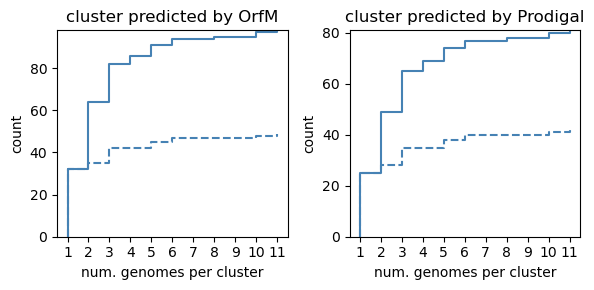

In [ ]:
print(f"Number of gene clusters (OrfM) at {MMSEQS_PARAMS['--min-seq-id']} identity:", genes_df.rep_gene_id.nunique())
print(f"Number of gene clusters (Prodigal) at {MMSEQS_PARAMS['--min-seq-id']} identity:", genes_df[~genes_df.prodigal_gene_id.isnull()].rep_gene_id.nunique())
print('Number of gene clusters present in all genomes:', genes_df[(genes_df.num_genomes_per_cluster > 10)].rep_gene_id.nunique())

fig, axes = plt.subplots(figsize=(6, 3), ncols=2)
figure_df = genes_df.groupby('rep_gene_id').size().reset_index(name='cluster_size')
figure_df['num_genomes_per_cluster']= figure_df.rep_gene_id.map(cluster_df.groupby('rep_gene_id').genome_id.nunique())
figure_df['cluster_predicted_by_prodigal'] = figure_df.rep_gene_id.map(genes_df.groupby('rep_gene_id').apply(lambda df : np.any(~df.prodigal_gene_id.isnull()), include_groups=False))
figure_df['cluster_has_annotation'] = figure_df.rep_gene_id.map(genes_df.groupby('rep_gene_id').apply(lambda df : np.any(df.has_annotation), include_groups=False))
figure_df = figure_df[(figure_df.num_genomes_per_cluster > 1) | (figure_df.cluster_has_annotation)].copy()

ax = axes[0]
ax.set_title('cluster predicted by OrfM')
sns.ecdfplot(figure_df, ax=ax, x='num_genomes_per_cluster', stat='count', color='steelblue')
sns.ecdfplot(figure_df[figure_df.cluster_has_annotation], ax=ax, x='num_genomes_per_cluster', stat='count', color='steelblue', ls='--')
ax.set_xticks(np.arange(1, 12), labels=np.arange(1, 12))
ax.set_ylabel('count')
ax.set_xlabel('num. genomes per cluster')

ax = axes[1]
ax.set_title('cluster predicted by Prodigal')
sns.ecdfplot(figure_df[figure_df.cluster_predicted_by_prodigal], ax=ax, x='num_genomes_per_cluster', stat='count', color='steelblue')
sns.ecdfplot(figure_df[figure_df.cluster_predicted_by_prodigal & figure_df.cluster_has_annotation], ax=ax, x='num_genomes_per_cluster', stat='count', color='steelblue', ls='--')
ax.set_xticks(np.arange(1, 12), labels=np.arange(1, 12))
ax.set_ylabel('count')
ax.set_xlabel('num. genomes per cluster')

fig.tight_layout()
plt.show()

In [ ]:
gene_ids = genes_df[genes_df.num_genomes_per_cluster > 10].gene_id.unique()
annot_df[annot_df.gene_id.isin(gene_ids)]
annot_df.annotation_status.value_counts()

# Need to figure out what to use for later in the pipeline. Do I use all OrfM genes? Or do I use only Prodigal-predicted ones?
# What about start site? Will it mess up the structures to extend past the start codon? Maybe embedding-based alignment similarity?

annotation_status
T    203
Name: count, dtype: int64

In [ ]:
# The ece.protein.faa file contains all proteins from the following projects:
#   (1) https://ggkbase.berkeley.edu/Borg_family_members/
#   (2) https://ggkbase.berkeley.edu/mp_ece/
#   (3) https://ggkbase.berkeley.edu/project_groups/borg-methanoperedens
#   (4) https://ggkbase.berkeley.edu/project_groups/borgs_mp_nanopore
figure_df.cluster_has_annotation.value_counts()


cluster_has_annotation
False    49
True     49
Name: count, dtype: int64

In [ ]:
gene_ids = genes_df[genes_df.prodigal_gene_id.isnull() & genes_df.has_annotation].gene_id.unique()
# gene_ids = genes_df[genes_df.prodigal_gene_id.isnull() & genes_df.has_annotation & (genes_df.num_genomes_per_cluster > 1)].gene_id.unique()

annot_df[annot_df.gene_id.isin(gene_ids)]

,gene_id,checksum,length,analysis,signature_accession,signature_description,annotation_start,annotation_stop,annotation_e_value,annotation_status,date,interpro_accession,interpro_description,go_terms,pathways
32,orfm.bz_2.1_47,15c0177e473ba50cb85a63bad7bde8c4,61,ProSiteProfiles,PS51257,Prokaryotic membrane lipoprotein lipid attachm...,1,19,6.0,T,15-06-2026,-,-,-,-
59,orfm.bz_7.1_5,784a8d1e900c378dc033a90c6b2a5d53,157,PANTHER,PTHR10068,BONE MARROW PROTEOGLYCAN,24,128,8.5E-14,T,15-06-2026,-,-,-,-
114,orfm.bz_8.1_139,4e748e78d575ee13870d28fc030c2b49,46,SUPERFAMILY,SSF144206,NOB1 zinc finger-like,6,42,3.92E-5,T,15-06-2026,IPR036283,NOB1 zinc finger-like superfamily,-,-
128,orfm.bz_7.1_208,c562ac9aec3366dcd1b52aebe85a73fe,84,Pfam,PF01391,Collagen triple helix repeat (20 copies),11,66,1.9E-4,T,15-06-2026,IPR008160,Collagen triple helix repeat,-,-
319,orfm.bz_8.1_86,82107fd8329209fa71255b08315cd22e,71,ProSiteProfiles,PS51257,Prokaryotic membrane lipoprotein lipid attachm...,1,32,5.0,T,15-06-2026,-,-,-,-
344,orfm.bz_10.1_94,ef2e2f129ca848d3c178d351b7652a22,32,ProSiteProfiles,PS50965,NERD domain profile.,1,32,9.057647,T,15-06-2026,IPR011528,"Nuclease-related domain, NERD",-,-
350,orfm.bz_7.1_27,25ab85c47cfb27dd66c5dc2364bf530f,193,PANTHER,PTHR36963,HELICASE,4,142,6.0E-10,T,15-06-2026,-,-,-,-
351,orfm.bz_7.1_27,25ab85c47cfb27dd66c5dc2364bf530f,193,Gene3D,G3DSA:2.160.20.80,-,2,163,2.4E-7,T,15-06-2026,-,-,-,-
352,orfm.bz_7.1_27,25ab85c47cfb27dd66c5dc2364bf530f,193,SUPERFAMILY,SSF141571,Pentapeptide repeat-like,18,140,5.4E-6,T,15-06-2026,-,-,-,-
412,orfm.bz_7.1_2,5d376acc0a0868520719196c2a050052,93,Pfam,PF01391,Collagen triple helix repeat (20 copies),11,63,0.0011,T,15-06-2026,IPR008160,Collagen triple helix repeat,-,-
